# Prueba de descarga de precios + backtest de contexto
Este notebook junta tus **dos códigos** para que puedas:
1) Descargar precios con `yfinance` y guardarlos en `./data/<TICKER>/`.
2) Ejecutar el análisis de contextos (caídas vs días de salida), ver gráficas y tabla de operaciones.

⚠️ Nota: si ejecutas esto en un entorno sin internet, la descarga puede fallar.

In [6]:
from __future__ import annotations

from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf

%matplotlib inline


## 1) Código 1 — Descarga y guardado de precios

In [3]:
def parse_tickers(tickers_input: str) -> List[str]:
    tickers = [t.strip().upper() for t in tickers_input.split(',') if t.strip()]
    if not tickers:
        raise ValueError('Debes introducir al menos un ticker.')
    return tickers


def download_ticker_data(
    tickers: List[str],
    base_dir: str | Path = 'data',
    days: int = 365,
) -> Dict[str, pd.DataFrame]:
    end = datetime.now()
    start = end - timedelta(days=days)

    base_path = Path(base_dir)
    base_path.mkdir(exist_ok=True)

    precios_por_ticker: Dict[str, pd.DataFrame] = {}

    for ticker in tickers:
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if raw.empty:
            print(f'No se encontraron datos para {ticker}.')
            continue

        # yfinance a veces devuelve MultiIndex en columnas
        if isinstance(raw.columns, pd.MultiIndex):
            close_series = raw.xs('Close', axis=1, level=0).iloc[:, 0]
        else:
            close_series = raw['Close']

        df = close_series.reset_index()
        df.columns = ['Date', 'Close']
        df['Date'] = pd.to_datetime(df['Date'])

        ticker_dir = base_path / ticker.replace('/', '_')
        ticker_dir.mkdir(parents=True, exist_ok=True)
        output_file = ticker_dir / f'{ticker}_precios.csv'
        df.to_csv(output_file, index=False)

        precios_por_ticker[ticker] = df
        print(f'{ticker}: datos guardados en {output_file}')

    if not precios_por_ticker:
        raise ValueError('No se pudo descargar informacion para los tickers proporcionados.')

    return precios_por_ticker


def load_from_prompt(days: int = 365) -> Dict[str, pd.DataFrame]:
    tickers_input = input('Introduce uno o varios tickers separados por coma (ej: TSLA, AAPL, SAN.MC): ').strip()
    tickers = parse_tickers(tickers_input)
    return download_ticker_data(tickers, days=days)


## 2) Código 2 — Backtest de contexto + visualización

In [4]:
def backtest_contexto(
    df: pd.DataFrame,
    ticker: str,
    caida_pct: int,
    hold_days: int,
    capital_start: float,
) -> Tuple[float, List[dict]]:
    work = df.copy().reset_index(drop=True)
    work['ret_diaria_pct'] = work['Close'].pct_change() * 100

    capital = capital_start
    operaciones: List[dict] = []
    i = 1

    while i < len(work) - hold_days:
        if work.loc[i, 'ret_diaria_pct'] <= -caida_pct:
            buy_i = i
            sell_i = i + hold_days

            precio_compra = float(work.loc[buy_i, 'Close'])
            precio_venta = float(work.loc[sell_i, 'Close'])
            capital_aportado = capital
            capital_liquidado = capital_aportado * (precio_venta / precio_compra)
            ret_op = (capital_liquidado / capital_aportado - 1) * 100

            operaciones.append(
                {
                    'Ticker': ticker,
                    'Caida_%': caida_pct,
                    'Dias_salida': hold_days,
                    'Fecha_inicio': work.loc[buy_i, 'Date'].date(),
                    'Fecha_final': work.loc[sell_i, 'Date'].date(),
                    'Precio_compra': round(precio_compra, 4),
                    'Precio_venta': round(precio_venta, 4),
                    'Capital_aportado': round(capital_aportado, 2),
                    'Capital_liquidado': round(capital_liquidado, 2),
                    'Rentabilidad_operacion_%': round(ret_op, 4),
                }
            )

            capital = capital_liquidado
            i = sell_i + 1
        else:
            i += 1

    rentabilidad_total = (capital / capital_start - 1) * 100
    return rentabilidad_total, operaciones


def run_context_analysis(
    precios_por_ticker: Dict[str, pd.DataFrame],
    capital_inicial: float = 10000.0,
    caidas: List[int] | None = None,
    dias_salida: List[int] | None = None,
    base_dir: str | Path = 'data',
) -> None:
    if caidas is None:
        caidas = list(range(3, 11))
    if dias_salida is None:
        dias_salida = list(range(1, 8))

    base_path = Path(base_dir)

    for ticker, df_ticker in precios_por_ticker.items():
        ticker_dir = base_path / ticker.replace('/', '_')

        resultados_por_caida = []
        for c in caidas:
            rentabilidades = [
                backtest_contexto(df_ticker, ticker, c, d, capital_inicial)[0]
                for d in dias_salida
            ]
            resultados_por_caida.append(sum(rentabilidades) / len(rentabilidades))

        resultados_por_dias = []
        for d in dias_salida:
            rentabilidades = [
                backtest_contexto(df_ticker, ticker, c, d, capital_inicial)[0]
                for c in caidas
            ]
            resultados_por_dias.append(sum(rentabilidades) / len(rentabilidades))

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(caidas, resultados_por_caida, marker='o')
        ax.set_title(f'{ticker} - Rentabilidad media vs caida (%)')
        ax.set_xlabel('Caida estudiada (%)')
        ax.set_ylabel('Rentabilidad obtenida (%)')
        ax.grid(True, alpha=0.3)
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(dias_salida, resultados_por_dias, marker='o', color='darkorange')
        ax.set_title(f'{ticker} - Rentabilidad media vs dias de salida')
        ax.set_xlabel('Dias hasta la venta')
        ax.set_ylabel('Rentabilidad obtenida (%)')
        ax.grid(True, alpha=0.3)
        plt.show()

        todas_operaciones: List[dict] = []
        for c in caidas:
            for d in dias_salida:
                _, ops = backtest_contexto(df_ticker, ticker, c, d, capital_inicial)
                todas_operaciones.extend(ops)

        tabla_ops = pd.DataFrame(todas_operaciones)
        if tabla_ops.empty:
            print(f'{ticker}: no hubo operaciones en los contextos evaluados.')
        else:
            tabla_ops = tabla_ops.sort_values(['Caida_%', 'Dias_salida', 'Fecha_inicio']).reset_index(drop=True)
            display(tabla_ops)
            out_csv = ticker_dir / f'{ticker}_operaciones_contextos.csv'
            tabla_ops.to_csv(out_csv, index=False)
            print(f'Tabla guardada en {out_csv}')


## 3) Ejecución rápida (modifica tickers/días/parametría)
Puedes ejecutar **A)** con input o **B)** sin input (lista fija).

PLTR: datos guardados en data/PLTR/PLTR_precios.csv
EPAM: datos guardados en data/EPAM/EPAM_precios.csv
OXY: datos guardados en data/OXY/OXY_precios.csv


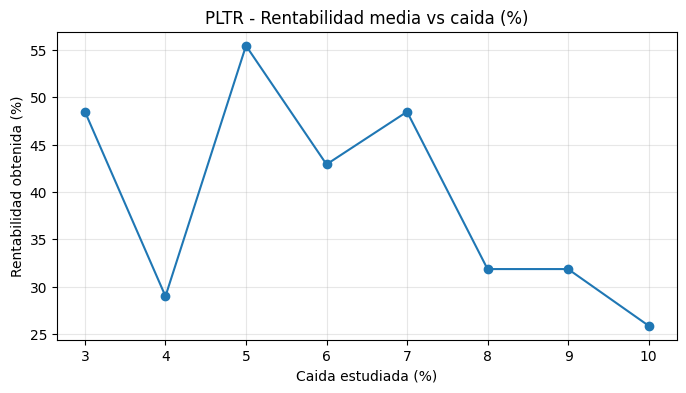

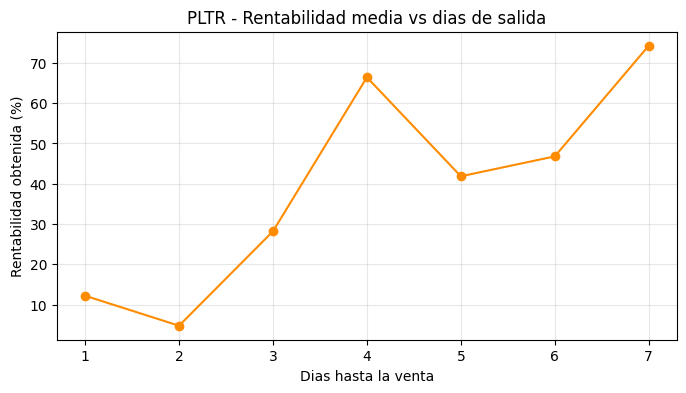

,Ticker,Caida_%,Dias_salida,Fecha_inicio,Fecha_final,Precio_compra,Precio_venta,Capital_aportado,Capital_liquidado,Rentabilidad_operacion_%
0,PLTR,3,1,2025-02-20,2025-02-21,106.27,101.35,10000.00,9537.03,-4.6297
1,PLTR,3,1,2025-02-24,2025-02-25,90.68,87.84,9537.03,9238.34,-3.1319
2,PLTR,3,1,2025-02-27,2025-02-28,84.77,84.92,9238.34,9254.69,0.1770
3,PLTR,3,1,2025-03-06,2025-03-07,80.46,84.91,9254.69,9766.54,5.5307
4,PLTR,3,1,2025-03-10,2025-03-11,76.38,78.05,9766.54,9980.08,2.1864
...,...,...,...,...,...,...,...,...,...,...
698,PLTR,10,7,2025-02-24,2025-03-05,90.68,90.13,10000.00,9939.35,-0.6065
699,PLTR,10,7,2025-03-06,2025-03-17,80.46,87.35,9939.35,10790.48,8.5633
700,PLTR,10,7,2025-04-04,2025-04-15,74.01,98.40,10790.48,14346.48,32.9550
701,PLTR,10,7,2025-05-06,2025-05-15,108.86,128.12,14346.48,16884.73,17.6924


Tabla guardada en data/PLTR/PLTR_operaciones_contextos.csv


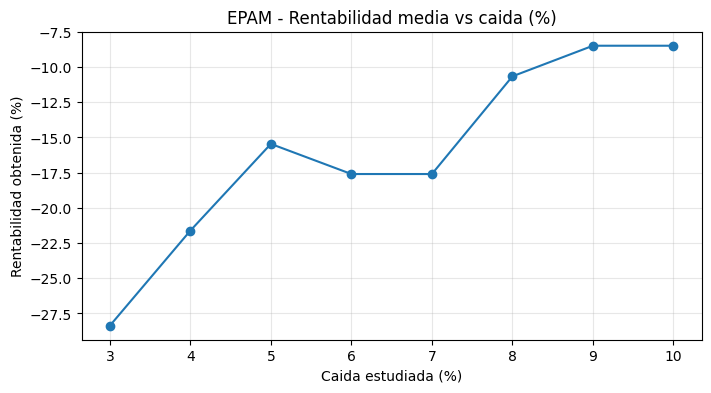

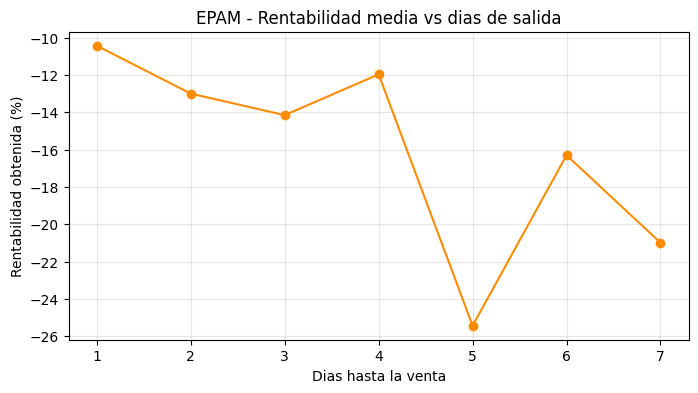

,Ticker,Caida_%,Dias_salida,Fecha_inicio,Fecha_final,Precio_compra,Precio_venta,Capital_aportado,Capital_liquidado,Rentabilidad_operacion_%
0,EPAM,3,1,2025-02-20,2025-02-21,225.07,208.84,10000.00,9278.89,-7.2111
1,EPAM,3,1,2025-03-03,2025-03-04,198.61,198.01,9278.89,9250.86,-0.3021
2,EPAM,3,1,2025-03-10,2025-03-11,190.41,191.36,9250.86,9297.01,0.4989
3,EPAM,3,1,2025-03-13,2025-03-14,180.16,182.73,9297.01,9429.64,1.4265
4,EPAM,3,1,2025-03-20,2025-03-21,172.28,175.30,9429.64,9594.93,1.7530
...,...,...,...,...,...,...,...,...,...,...
354,EPAM,10,5,2026-02-03,2026-02-10,183.33,191.61,9255.34,9673.35,4.5164
355,EPAM,10,6,2025-02-20,2025-02-28,225.07,206.14,10000.00,9158.93,-8.4107
356,EPAM,10,6,2026-02-03,2026-02-11,183.33,177.99,9158.93,8892.15,-2.9128
357,EPAM,10,7,2025-02-20,2025-03-03,225.07,198.61,10000.00,8824.37,-11.7563


Tabla guardada en data/EPAM/EPAM_operaciones_contextos.csv


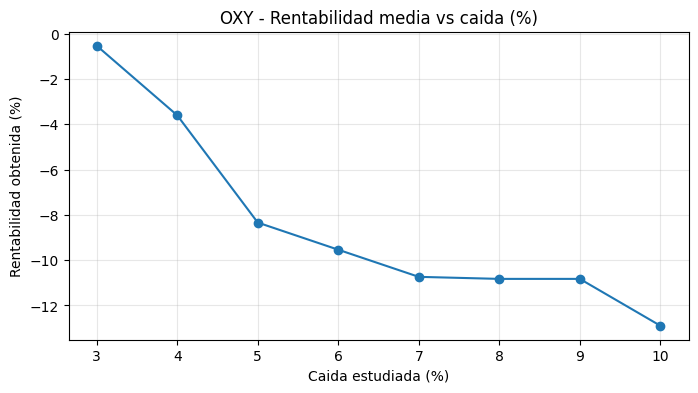

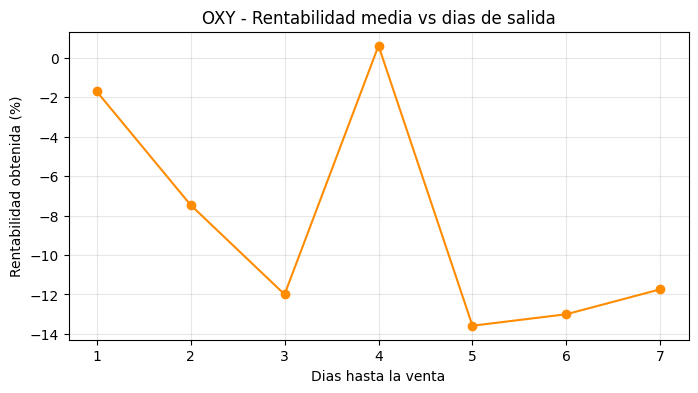

,Ticker,Caida_%,Dias_salida,Fecha_inicio,Fecha_final,Precio_compra,Precio_venta,Capital_aportado,Capital_liquidado,Rentabilidad_operacion_%
0,OXY,3,1,2025-02-21,2025-02-24,49.3336,48.7856,10000.00,9888.93,-1.1107
1,OXY,3,1,2025-03-03,2025-03-04,45.4491,45.5274,9888.93,9905.97,0.1722
2,OXY,3,1,2025-04-03,2025-04-04,43.1734,39.8690,9905.97,9147.79,-7.6538
3,OXY,3,1,2025-04-07,2025-04-08,38.1086,35.5123,9147.79,8524.56,-6.8129
4,OXY,3,1,2025-04-10,2025-04-11,35.8664,37.0465,8524.56,8805.05,3.2904
...,...,...,...,...,...,...,...,...,...,...
228,OXY,10,3,2025-04-03,2025-04-08,43.1734,35.5123,10000.00,8225.51,-17.7449
229,OXY,10,4,2025-04-03,2025-04-09,43.1734,39.5641,10000.00,9164.01,-8.3599
230,OXY,10,5,2025-04-03,2025-04-10,43.1734,35.8664,10000.00,8307.52,-16.9248
231,OXY,10,6,2025-04-03,2025-04-11,43.1734,37.0465,10000.00,8580.87,-14.1913


Tabla guardada en data/OXY/OXY_operaciones_contextos.csv


In [7]:
# B) Sin input (recomendado para repetir pruebas)
tickers = ['PLTR', 'EPAM', 'OXY']  # cambia aquí
precios = download_ticker_data(tickers, days=365)

# Parametría (ajusta a tu gusto)
capital_inicial = 10000.0
caidas = list(range(3, 11))       # 3%..10%
dias_salida = list(range(1, 8))   # 1..7 días

run_context_analysis(
    precios,
    capital_inicial=capital_inicial,
    caidas=caidas,
    dias_salida=dias_salida,
    base_dir='data'
)
